### <span style="color:purple; font-size:1.5em; font-weight:bold;">Decision Tree Classification</span>


**Task I am doing:** I am building and evaluating a Decision Tree classifier using the `car_evaluation.csv` dataset, and then comparing model performance before and after hyperparameter tuning.

# ~ Load the "car_evaluation.csv" dataset
We begin by loading and exploring the dataset. It contains categorical features related to car evaluations, such as buying price, maintenance cost, and safety level. The target variable is the car's evaluation class.


In [524]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

In [525]:
df = pd.read_csv("car_evaluation.csv")
print(df.head())
print(df.info())

  buying  maint doors persons lug_boot safety  class
0  vhigh  vhigh     2       2    small    low  unacc
1  vhigh  vhigh     2       2    small    med  unacc
2  vhigh  vhigh     2       2    small   high  unacc
3  vhigh  vhigh     2       2      med    low  unacc
4  vhigh  vhigh     2       2      med    med  unacc
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   buying    1728 non-null   object
 1   maint     1728 non-null   object
 2   doors     1728 non-null   object
 3   persons   1728 non-null   object
 4   lug_boot  1728 non-null   object
 5   safety    1728 non-null   object
 6   class     1728 non-null   object
dtypes: object(7)
memory usage: 94.6+ KB
None


In [526]:
df.columns

Index(['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class'], dtype='object')

# ~ Data Preprocessing using Label Encoder
We apply Label Encoding to convert categorical variables into numerical form, which is suitable for Decision Tree algorithms.

In [527]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in df.columns:
    df[col] = le.fit_transform(df[col])

In [528]:
# Display the first 5 rows after encoding
print(df.head())

   buying  maint  doors  persons  lug_boot  safety  class
0       3      3      0        0         2       1      2
1       3      3      0        0         2       2      2
2       3      3      0        0         2       0      2
3       3      3      0        0         1       1      2
4       3      3      0        0         1       2      2


#Split Features and Target

In [529]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

#Split the Dataset

We split the dataset into 70% training and 30% testing sets to evaluate model generalization.

In [530]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.7, random_state=42
)

# ~ Training Decision Tree

In [531]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

dt = DecisionTreeClassifier(max_depth=3)
dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3)

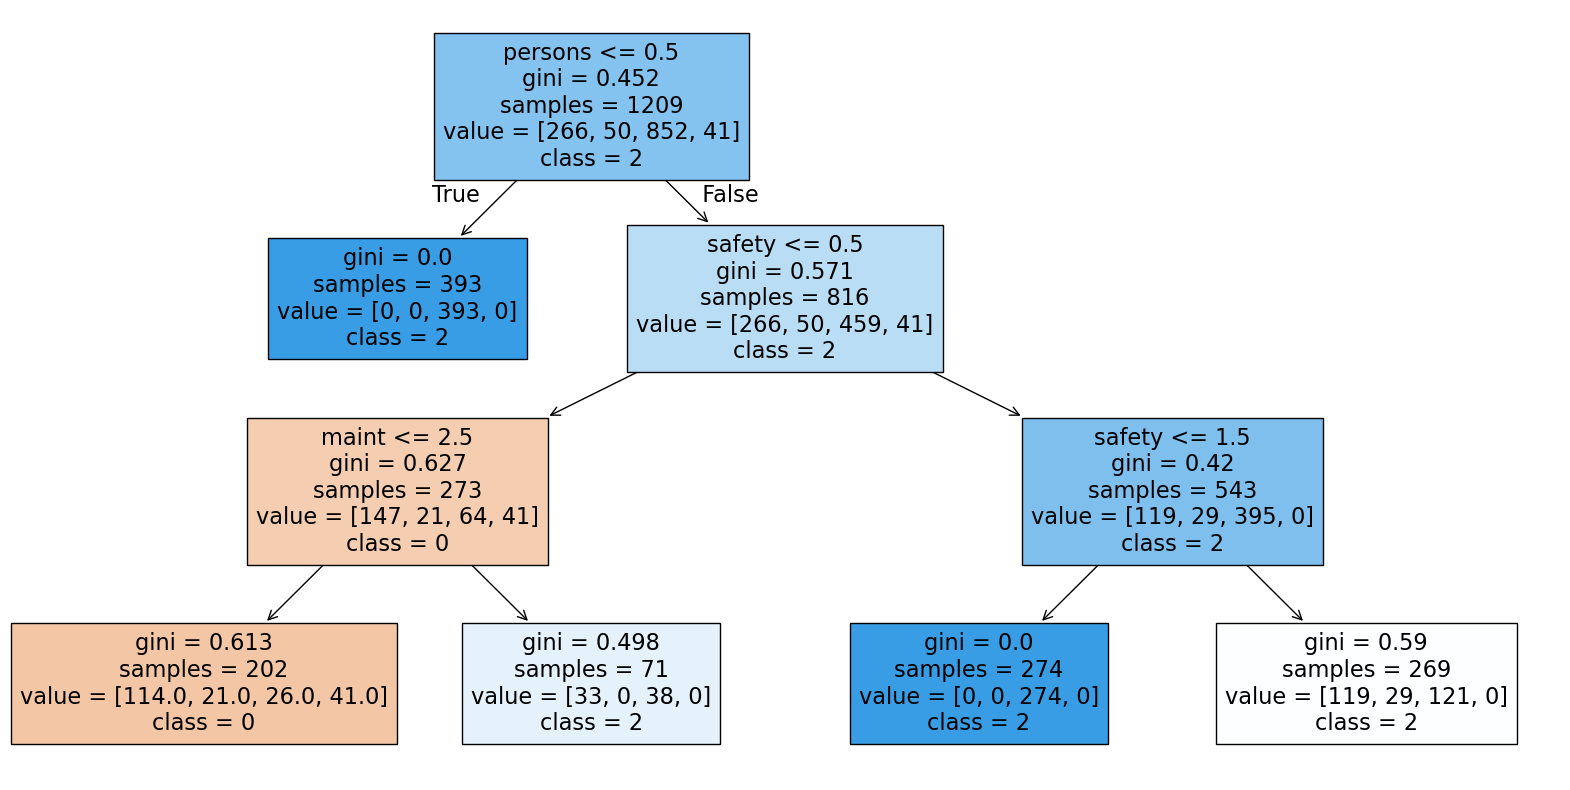

In [532]:
plt.figure(figsize=(20, 10))
plot_tree(dt, feature_names=X.columns, class_names=[str(i) for i in sorted(set(y))]
, filled=True)
plt.show()

We evaluate the accuracy, confusion matrix, and classification report for the base Decision Tree model.

In [533]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = dt.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7572254335260116
Confusion Matrix:
 [[ 44   0  74   0]
 [  9   0  10   0]
 [  9   0 349   0]
 [ 24   0   0   0]]
Classification Report:
               precision    recall  f1-score   support

           0       0.51      0.37      0.43       118
           1       0.00      0.00      0.00        19
           2       0.81      0.97      0.88       358
           3       0.00      0.00      0.00        24

    accuracy                           0.76       519
   macro avg       0.33      0.34      0.33       519
weighted avg       0.67      0.76      0.71       519



/home/btech/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/btech/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/btech/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


The initial model struggles with minority classes (e.g., class 1 and 3), predicting only the dominant class. This indicates underfitting and a need for deeper trees.

# ~ Hyper Parameter Tuning

In [534]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt

# Define the parameter grid
params = {
    'max_depth': [2, 3, 5, 10, 20],
    'min_samples_leaf': [5, 10, 20, 50, 100],
    'criterion': ["gini", "entropy"]
}

#Initialize the model

In [535]:
dt = DecisionTreeClassifier(random_state=42)

#Performing GridSearchCV

We perform hyperparameter tuning using a grid of depth, leaf size, and splitting criteria. Cross-validation with 4 folds is used for robust evaluation.

In [536]:
grid_search = GridSearchCV(estimator=dt, 
                           param_grid=params, 
                           cv=4, 
                           n_jobs=-1, 
                           verbose=1, 
                           scoring="accuracy")


In [537]:
# Fit the model
grid_search.fit(X_train, y_train)

Fitting 4 folds for each of 50 candidates, totalling 200 fits


GridSearchCV(cv=4, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [2, 3, 5, 10, 20],
                         'min_samples_leaf': [5, 10, 20, 50, 100]},
             scoring='accuracy', verbose=1)

In [538]:
# Get best estimator
dt_best = grid_search.best_estimator_

In [539]:
y_train_pred = dt_best.predict(X_train)
y_test_pred = dt_best.predict(X_test)

We evaluate the model with the best parameters from GridSearchCV on both training and testing sets.

In [540]:
print("Train Accuracy :", accuracy_score(y_train, y_train_pred))
print("Train Confusion Matrix:\n", confusion_matrix(y_train, y_train_pred))
print("-" * 50)
print("Test Accuracy :", accuracy_score(y_test, y_test_pred))
print("Test Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))
print("\nClassification Report:\n", classification_report(y_test, y_test_pred))

Train Accuracy : 0.9760132340777502
Train Confusion Matrix:
 [[259   2   5   0]
 [  3  43   3   1]
 [ 13   0 839   0]
 [  2   0   0  39]]
--------------------------------------------------
Test Accuracy : 0.9441233140655106
Test Confusion Matrix:
 [[104   9   4   1]
 [  3  14   0   2]
 [  7   0 351   0]
 [  3   0   0  21]]

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.88      0.89       118
           1       0.61      0.74      0.67        19
           2       0.99      0.98      0.98       358
           3       0.88      0.88      0.88        24

    accuracy                           0.94       519
   macro avg       0.84      0.87      0.85       519
weighted avg       0.95      0.94      0.95       519



#Visualize Decision Tree

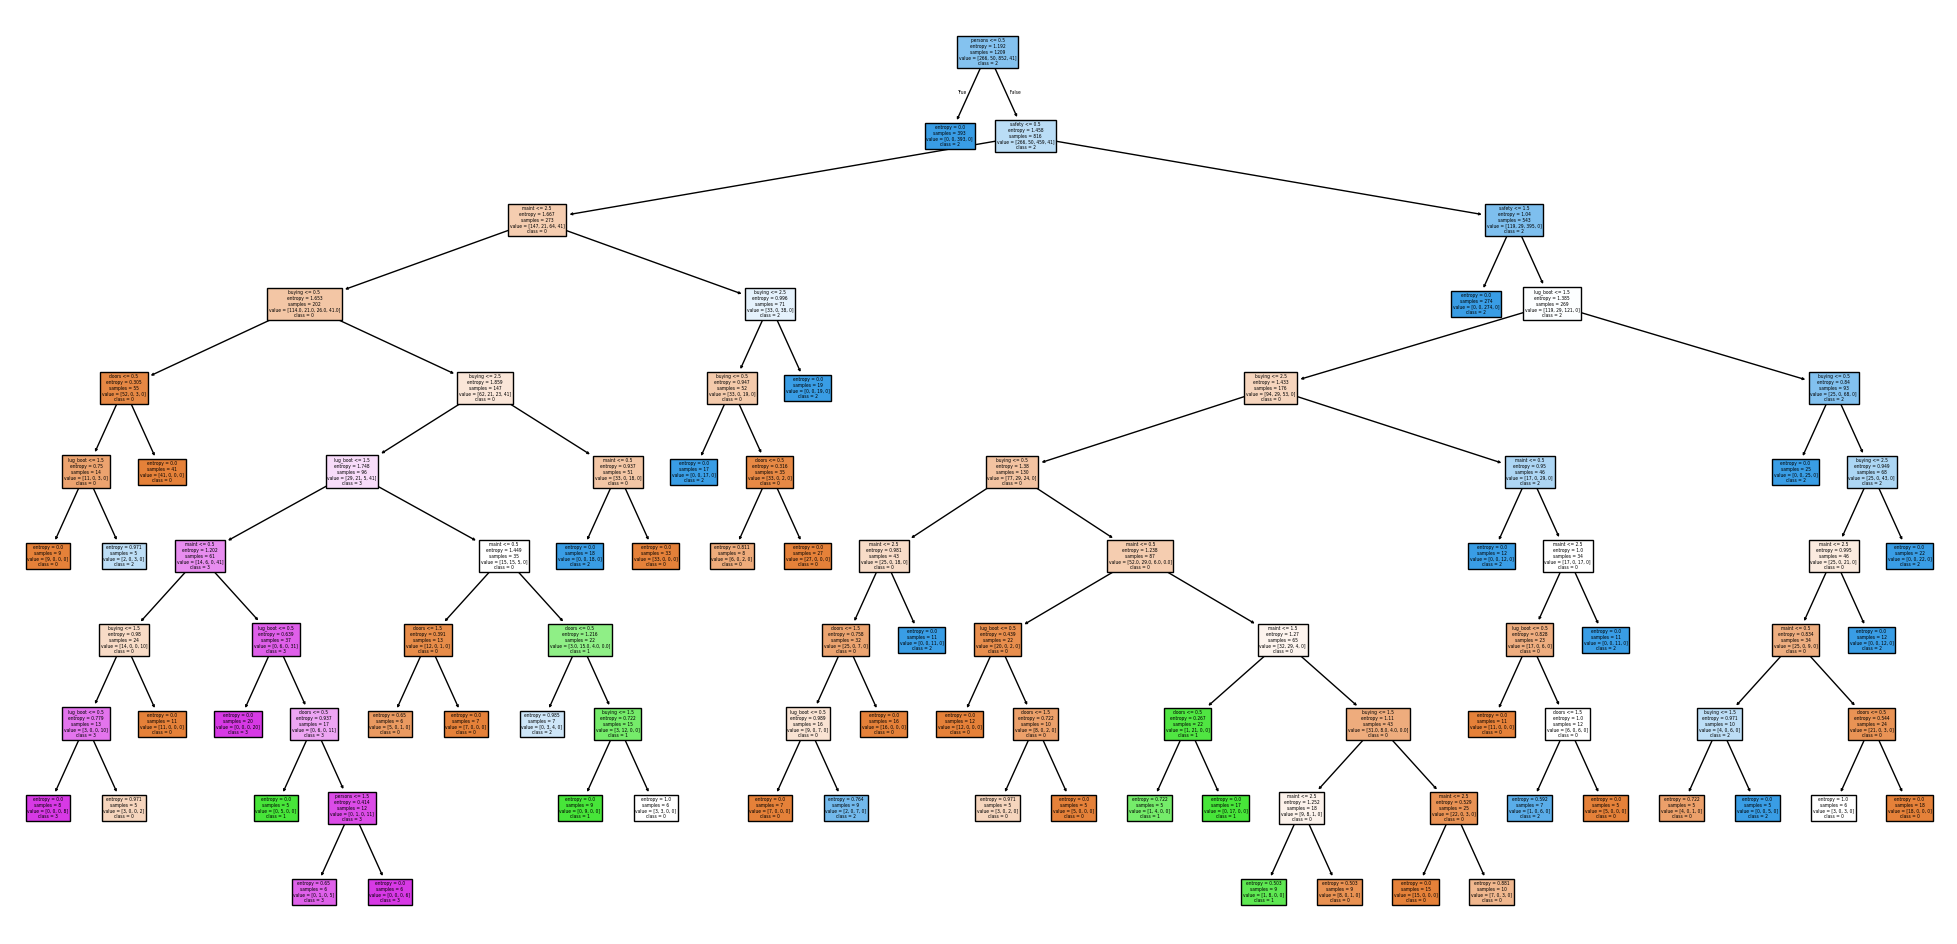

In [541]:
plt.figure(figsize=(25,12))
plot_tree(dt_best, feature_names=X.columns, class_names=[str(i) for i in set(y)], filled=True)
plt.show()


##  Conclusion

- The initial Decision Tree (max_depth=3) showed limited performance due to underfitting.
- After hyperparameter tuning using GridSearchCV, accuracy improved significantly to **94.4%**.
- Class imbalance was handled better with a deeper tree and proper leaf size, enhancing generalization.
